In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm

In [17]:
df = pd.DataFrame(columns=['timepoint', 'ribose', 'Jahin_nuclei_count', 'Jahin_Delauney'])

df = pd.DataFrame(data = {'timepoint': ['24', '96'], 'ribose': [0, 0], 'Jahin_nuclei_count': [208, 288], 'Jahin_Delauney': [153, 209], 'Jahin_spheroid_diameter': [35, 45]})
df.loc[len(df)] = ["24", 50, 173, 117, 37]
df.loc[len(df)] = ["96", 50, 201, 79, 41]
df.loc[len(df)] = ["24", 200, 177, 150, 36]
df.loc[len(df)] = ["96", 200, 159, 107, 38]

# Sort unique ribose levels
ribose_levels = sorted(df["ribose"].unique())

# Map to evenly spaced positions along the colormap
positions = np.linspace(0, 1, len(ribose_levels))  # 0, 0.5, 1
cmap = plt.cm.winter_r
palette = {level: cmap(pos) for level, pos in zip(ribose_levels, positions)}

In [18]:
df['Spheroid_Volume'] = (4/3) * np.pi * (df['Jahin_spheroid_diameter']/2)**3
df['Spheroid_CrossSection_Area'] = np.pi * (df['Jahin_spheroid_diameter']/2)**2
df['volume_per_cell'] = df['Spheroid_Volume']/df['Jahin_nuclei_count']
df['area_per_cell'] = df['Spheroid_CrossSection_Area']/df['Jahin_nuclei_count']
df['cell_radius_from_volume'] = np.power( (3/(np.pi*4)) * df['volume_per_cell'], 1/3 )
df['cell_radius_from_area'] = np.power( df['area_per_cell'] / np.pi, 1/2 )

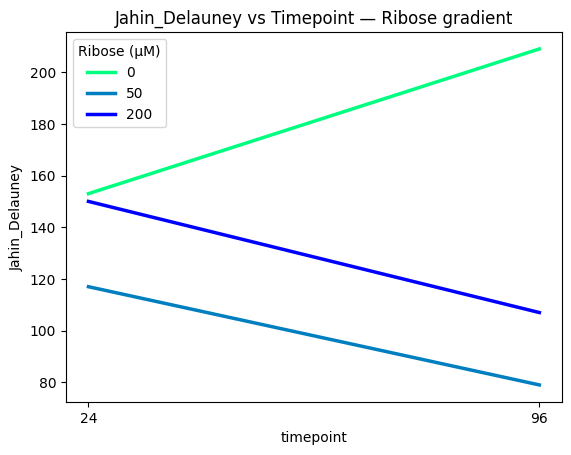

In [19]:

sns.lineplot(
    data=df,
    x="timepoint", y="Jahin_Delauney",
    hue="ribose",
    palette=palette,
    linewidth=2.5
)

plt.title("Jahin_Delauney vs Timepoint — Ribose gradient")
plt.legend(title="Ribose (µM)")
plt.show()


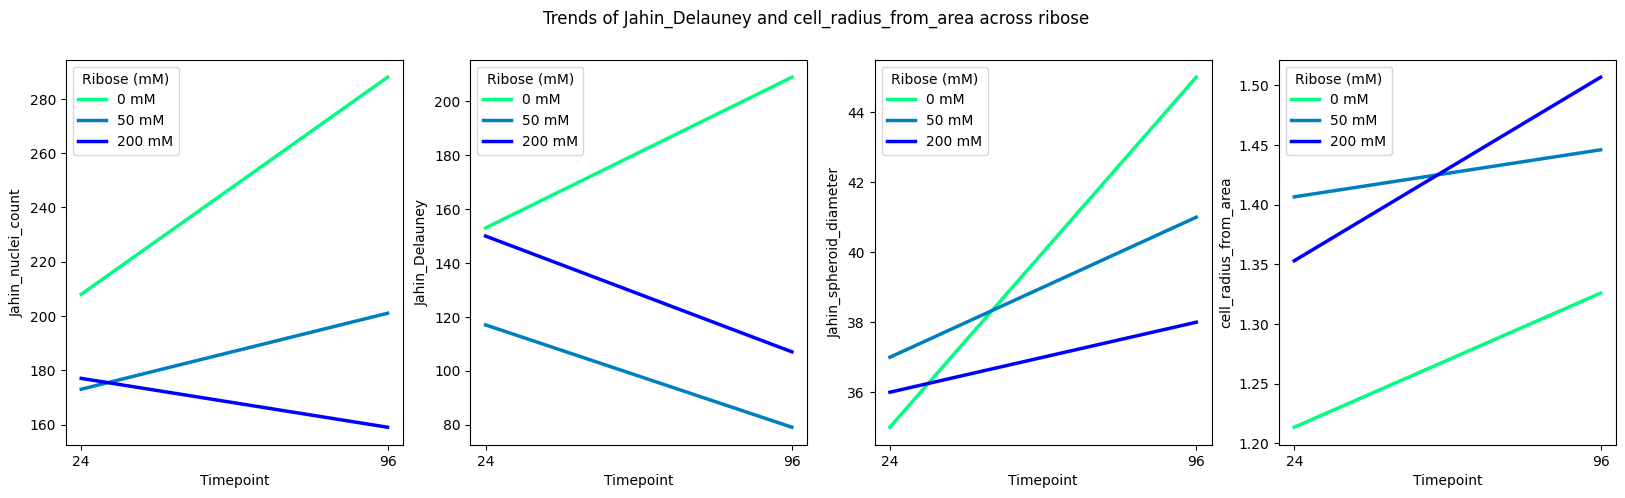

In higher stiffness, cell nuclei get closer together. But cell radius gets larger?


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20,5), sharex=True)

for rib in ribose_levels:
    subset = df[df["ribose"] == rib].sort_values("timepoint")
    axes[0].plot(subset["timepoint"], subset["Jahin_nuclei_count"], color=palette[rib], linewidth=2.5, label=f"{rib} mM")
    axes[1].plot(subset["timepoint"], subset["Jahin_Delauney"], color=palette[rib], linewidth=2.5, label=f"{rib} mM")
    axes[2].plot(subset["timepoint"], subset["Jahin_spheroid_diameter"], color=palette[rib], linewidth=2.5, label=f"{rib} mM")
    axes[3].plot(subset["timepoint"], subset["cell_radius_from_area"], color=palette[rib], linewidth=2.5, label=f"{rib} mM")

axes[0].set_ylabel("Jahin_nuclei_count")
axes[1].set_ylabel("Jahin_Delauney")
axes[2].set_ylabel("Jahin_spheroid_diameter")
axes[3].set_ylabel("cell_radius_from_area")
for ax in axes:
    ax.set_xlabel("Timepoint")
    ax.legend(title="Ribose (mM)")

plt.suptitle("Trends of Jahin_Delauney and cell_radius_from_area across ribose")
plt.savefig('ribose.pdf')
plt.show()
print("In higher stiffness, cell nuclei get closer together. But cell radius gets larger?")


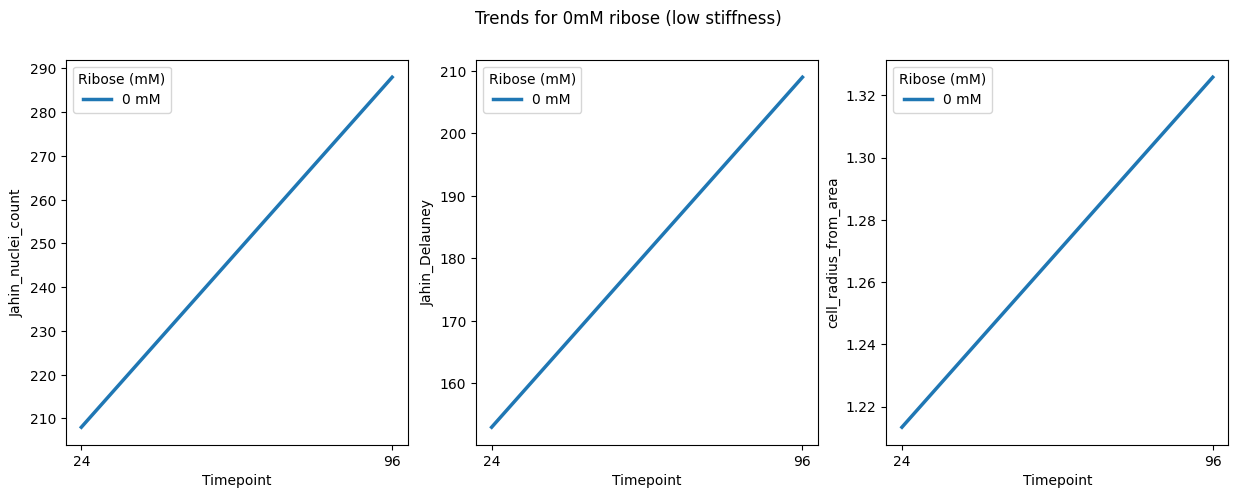

In higher stiffness, cell nuclei get closer together. But cell radius gets larger?


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True)

for rib in [0]:
    subset = df[df["ribose"] == rib].sort_values("timepoint")
    axes[0].plot(subset["timepoint"], subset["Jahin_nuclei_count"], linewidth=2.5, label=f"{rib} mM")
    axes[1].plot(subset["timepoint"], subset["Jahin_Delauney"], linewidth=2.5, label=f"{rib} mM")
    axes[2].plot(subset["timepoint"], subset["cell_radius_from_area"], linewidth=2.5, label=f"{rib} mM")

axes[0].set_ylabel("Jahin_nuclei_count")
axes[1].set_ylabel("Jahin_Delauney")
axes[2].set_ylabel("cell_radius_from_area")
for ax in axes:
    ax.set_xlabel("Timepoint")
    ax.legend(title="Ribose (mM)")

plt.suptitle("Trends for 0mM ribose (low stiffness)")
plt.savefig('ribose_0.pdf')
plt.show()
print("In higher stiffness, cell nuclei get closer together. But cell radius gets larger?")



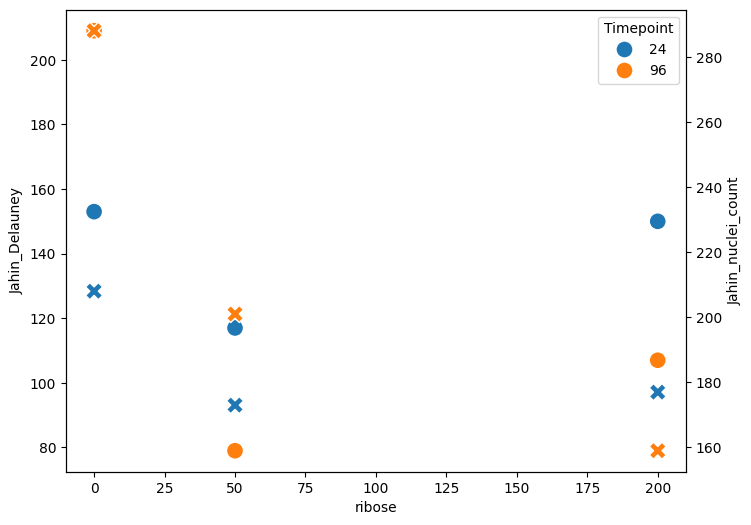

In [11]:
fig, ax1 = plt.subplots(figsize=(8,6))

# Left axis
sns.scatterplot(
    data=df,
    x="ribose", y="Jahin_Delauney",
    hue="timepoint",
    s=150,
    marker="o",
    ax=ax1,
)

ax1.set_ylabel("Jahin_Delauney")

# Right axis
ax2 = ax1.twinx()

sns.scatterplot(
    data=df,
    x="ribose", y="Jahin_nuclei_count",
    hue="timepoint",
    s=150,
    marker="X",
    ax=ax2,
    legend=False  # prevent duplicate legend
)

ax2.set_ylabel("Jahin_nuclei_count")

# Combine legends properly
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles, title="Timepoint", loc='best')

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="ribose", y="cell_radius_from_area",
    hue="timepoint",
    s=150,
    marker="o",  # circles
    legend=False  # avoid duplicate legends
)

sns.scatterplot(
    data=df,
    x="ribose", y="cell_radius_from_volume",
    hue="timepoint",
    s=150,
    marker="X",  # crosses (you can choose e.g. "s", "^", "D", etc.)
)

plt.legend(title="Timepoint")
plt.show()
